In [2]:
# Standard libraries
import os
import random
import copy

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch and torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import EuroSAT
import torchvision.transforms.v2 as T

# Splitting, metrics, progress, and model summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.auto import tqdm
from torchinfo import summary

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# **EuroSat Dataset Pipeline**

In [4]:
directory = 'kaggle/working/data'
dataset = EuroSAT(
    root = directory,
    download = True
)
print('Dataset Size: ', len(dataset))
image, label = dataset[0]
print('Image Size: ', image.size)
print('Available Classes: ', dataset.classes)
print('Class Mapping :\n', dataset.class_to_idx)

100%|██████████| 94.3M/94.3M [00:01<00:00, 79.0MB/s]


Dataset Size:  27000
Image Size:  (64, 64)
Available Classes:  ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class Mapping :
 {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


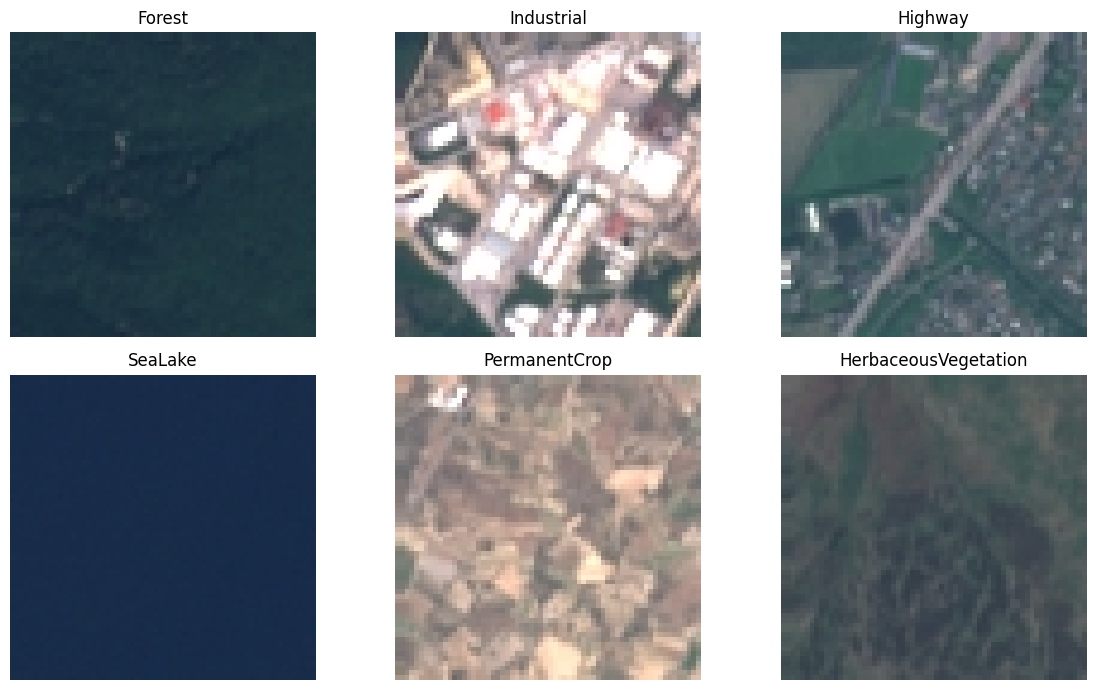

In [5]:
# Visualize random samples
num_images = 6
random_indices = random.sample(range(len(dataset)), num_images)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    image, label = dataset[idx]

    ax.imshow(image)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# **Data Processing**

In [6]:
# Split configuration
SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
TEST_SIZE = 0.15
DEV_SIZE = 0.15

# Get sample indices and labels
indices = np.arange(len(dataset))
labels = np.array(dataset.targets)

# Split off the locked test set
train_dev_indices, test_indices = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels
)

# Get labels for the remaining train + development data
train_dev_labels = labels[train_dev_indices]

# Calculate development size relative to the remaining data
dev_relative_size = DEV_SIZE / (1 - TEST_SIZE)

# Split remaining data into training and development sets
train_indices, dev_indices = train_test_split(
    train_dev_indices,
    test_size=dev_relative_size,
    random_state=SEED,
    stratify=train_dev_labels
)

print(f"Training set:    {len(train_indices)}")
print(f"Development set: {len(dev_indices)}")
print(f"Test set:        {len(test_indices)}")

Training set:    18899
Development set: 4051
Test set:        4050


In [7]:
# Transforms
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(10),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

eval_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

# Separate dataset copies for training and evaluation transforms
train_base = copy.deepcopy(dataset)
eval_base = copy.deepcopy(dataset)

train_base.transform = train_transform
eval_base.transform = eval_transform

# DataLoader settings
BATCH_SIZE = 64
NUM_WORKERS = 0

# Training subset
train_subset = Subset(
    train_base,
    train_indices
)

# Development subset
dev_subset = Subset(
    eval_base,
    dev_indices
)

# Test subset
test_subset = Subset(
    eval_base,
    test_indices
)

# Training loader
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Development loader
dev_loader = DataLoader(
    dev_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Test loader
test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# **Model Design**

**Specific blocks**


In [8]:
# Convolution block
class ConvBnRelu(nn.Sequential):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.1):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                stride=stride,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout)
        )


# Transposed convolution block
class TransConvBnRelu(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


# **Sat_CNN**

In [9]:
class Sat_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            ConvBnRelu(3, 20),
            nn.MaxPool2d(2),

            ConvBnRelu(20, 40),
            nn.MaxPool2d(2),

            ConvBnRelu(40, 68),
            nn.MaxPool2d(2),

            ConvBnRelu(68, 96),
            nn.MaxPool2d(2),

            ConvBnRelu(96, 116)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(116, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

# **Auto Encoder**

In [10]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # [B, 3, 64, 64] -> [B, 18, 32, 32]
            ConvBnRelu(3, 18, stride=2),

            # [B, 18, 32, 32] -> [B, 28, 16, 16]
            ConvBnRelu(18, 28, stride=2),

            # [B, 28, 16, 16] -> [B, 48, 8, 8]
            ConvBnRelu(28, 48, stride=2)
        )

        self.decoder = nn.Sequential(
            # [B, 48, 8, 8] -> [B, 28, 16, 16]
            TransConvBnRelu(48, 28),

            # [B, 28, 16, 16] -> [B, 18, 32, 32]
            TransConvBnRelu(28, 18),

            # [B, 18, 32, 32] -> [B, 12, 64, 64]
            TransConvBnRelu(18, 12),

            # [B, 12, 64, 64] -> [B, 3, 64, 64]
            nn.Conv2d(
                12,
                3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x


# **Model Summary**

In [11]:
# Model summary function
def show_model_summary(model, input_size=(1, 3, 64, 64)):
    return summary(
        model,
        input_size=input_size,
        col_names=[
            "input_size",
            "output_size",
            "num_params",
            "trainable"
        ],
        mode="eval",
        depth=4
    )

# **Train function for Sat_CNN**

In [12]:
def get_metrics(labels, predictions):
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

In [13]:
def train_classifier(
    model,
    train_loader,
    dev_loader,
    optimizer,
    criterion,
    epochs,
    device,
    checkpoint_dir="checkpoints",
    resume=True,
    preprocessor=None
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    state_path = os.path.join(
        checkpoint_dir,
        "latest_state.pt"
    )

    model = model.to(device)

    # Optional frozen preprocessing model, used by ae_sat_cnn.
    if preprocessor is not None:
        preprocessor = preprocessor.to(device)
        preprocessor.eval()

        for parameter in preprocessor.parameters():
            parameter.requires_grad = False

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "dev_accuracy": [],
        "train_precision": [],
        "dev_precision": [],
        "train_recall": [],
        "dev_recall": [],
        "train_f1": [],
        "dev_f1": []
    }

    top_checkpoints = []
    start_epoch = 1

    # Resume previous training
    if resume and os.path.exists(state_path):

        state = torch.load(
            state_path,
            map_location=device
        )

        model.load_state_dict(
            state["model_state_dict"]
        )

        optimizer.load_state_dict(
            state["optimizer_state_dict"]
        )

        history = state["history"]
        top_checkpoints = state["top_checkpoints"]

        start_epoch = state["epoch"] + 1

        print(
            f"Resuming from epoch "
            f"{state['epoch']}"
        )

        print("Current top checkpoints:")

        for checkpoint in top_checkpoints:
            print(
                f"Epoch {checkpoint['epoch']} | "
                f"Loss: {checkpoint['dev_loss']:.4f} | "
                f"F1: {checkpoint['dev_f1']:.4f}"
            )

    for epoch in range(start_epoch, epochs + 1):

        # Training
        model.train()

        train_loss = 0.0
        train_samples = 0

        train_labels = []
        train_predictions = []

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} Train",
            leave=False
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # For ae_sat_cnn, reconstruct the input first.
            if preprocessor is not None:
                with torch.no_grad():
                    images = preprocessor(images)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            batch_size = images.size(0)

            train_loss += (
                loss.item() * batch_size
            )

            train_samples += batch_size

            predictions = outputs.argmax(dim=1)

            train_labels.extend(
                labels.detach().cpu().numpy()
            )

            train_predictions.extend(
                predictions.detach().cpu().numpy()
            )

        train_loss /= train_samples

        train_metrics = get_metrics(
            train_labels,
            train_predictions
        )

        # Development
        model.eval()

        dev_loss = 0.0
        dev_samples = 0

        dev_labels = []
        dev_predictions = []

        with torch.no_grad():

            for images, labels in tqdm(
                dev_loader,
                desc=f"Epoch {epoch}/{epochs} Dev",
                leave=False
            ):

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                # For ae_sat_cnn, reconstruct the development input first.
                if preprocessor is not None:
                    images = preprocessor(images)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                batch_size = images.size(0)

                dev_loss += (
                    loss.item() * batch_size
                )

                dev_samples += batch_size

                predictions = outputs.argmax(dim=1)

                dev_labels.extend(
                    labels.cpu().numpy()
                )

                dev_predictions.extend(
                    predictions.cpu().numpy()
                )

        dev_loss /= dev_samples

        dev_metrics = get_metrics(
            dev_labels,
            dev_predictions
        )

        # Store history
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["dev_accuracy"].append(
            dev_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["dev_precision"].append(
            dev_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["dev_recall"].append(
            dev_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["dev_f1"].append(
            dev_metrics["f1"]
        )

        # Current checkpoint
        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"best_epoch_{epoch}.pt"
        )

        checkpoint_info = {
            "epoch": epoch,
            "dev_loss": dev_loss,
            "dev_f1": dev_metrics["f1"],
            "path": checkpoint_path
        }

        top_checkpoints.append(
            checkpoint_info
        )

        # Sort by lowest development loss
        top_checkpoints = sorted(
            top_checkpoints,
            key=lambda x: x["dev_loss"]
        )

        # Save if current model is in top 3
        if checkpoint_info in top_checkpoints[:3]:

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "dev_loss": dev_loss,
                    "dev_accuracy": dev_metrics["accuracy"],
                    "dev_precision": dev_metrics["precision"],
                    "dev_recall": dev_metrics["recall"],
                    "dev_f1": dev_metrics["f1"]
                },
                checkpoint_path
            )

        # Delete checkpoints outside top 3
        removed_checkpoints = top_checkpoints[3:]

        for checkpoint in removed_checkpoints:

            if os.path.exists(checkpoint["path"]):
                os.remove(checkpoint["path"])

        top_checkpoints = top_checkpoints[:3]

        # Save latest state
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "top_checkpoints": top_checkpoints
            },
            state_path
        )

        # Print epoch results
        print(f"\nEpoch {epoch:02d}/{epochs}")

        print(
            f"Train | "
            f"Loss: {train_loss:.4f} | "
            f"Acc: {train_metrics['accuracy']:.4f} | "
            f"Prec: {train_metrics['precision']:.4f} | "
            f"Recall: {train_metrics['recall']:.4f} | "
            f"F1: {train_metrics['f1']:.4f}"
        )

        print(
            f"Dev   | "
            f"Loss: {dev_loss:.4f} | "
            f"Acc: {dev_metrics['accuracy']:.4f} | "
            f"Prec: {dev_metrics['precision']:.4f} | "
            f"Recall: {dev_metrics['recall']:.4f} | "
            f"F1: {dev_metrics['f1']:.4f}"
        )

    # Select highest F1 among 3 lowest-loss models
    best_checkpoint = max(
        top_checkpoints,
        key=lambda x: x["dev_f1"]
    )

    selected = torch.load(
        best_checkpoint["path"],
        map_location=device
    )

    model.load_state_dict(
        selected["model_state_dict"]
    )

    print("\nSelected Model")

    print(
        f"Epoch: {selected['epoch']} | "
        f"Dev Loss: {selected['dev_loss']:.4f} | "
        f"Dev Acc: {selected['dev_accuracy']:.4f} | "
        f"Dev F1: {selected['dev_f1']:.4f}"
    )

    return model, history, top_checkpoints

# **Training Sat_CNN and showing learning curves**

In [14]:
# Create the only classifier architecture.
sat_cnn = Sat_CNN(num_classes=len(dataset.classes)).to(device)

In [15]:
show_model_summary(sat_cnn)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Sat_CNN                                  [1, 3, 64, 64]            [1, 10]                   --                        True
├─Sequential: 1-1                        [1, 3, 64, 64]            [1, 116, 4, 4]            --                        True
│    └─ConvBnRelu: 2-1                   [1, 3, 64, 64]            [1, 20, 64, 64]           --                        True
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            [1, 20, 64, 64]           540                       True
│    │    └─BatchNorm2d: 3-2             [1, 20, 64, 64]           [1, 20, 64, 64]           40                        True
│    │    └─ReLU: 3-3                    [1, 20, 64, 64]           [1, 20, 64, 64]           --                        --
│    │    └─Dropout2d: 3-4               [1, 20, 64, 64]           [1, 20, 64, 64]           --                        --
│    └─

In [16]:
# Use two GPUs when available; also works on one GPU or CPU.
if torch.cuda.device_count() >= 2 and not isinstance(sat_cnn, nn.DataParallel):
    sat_cnn = nn.DataParallel(sat_cnn, device_ids=[0, 1], output_device=0)

classification_criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(sat_cnn.parameters(), lr=1e-3, weight_decay=1e-4)

In [17]:
total_params = sum(
    p.numel()
    for p in sat_cnn.parameters()
)

trainable_params = sum(
    p.numel()
    for p in sat_cnn.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 200014
Trainable parameters: 200014


In [18]:
# Train model
sat_cnn, sat_history, sat_checkpoints = train_classifier(
    model=sat_cnn,
    train_loader=train_loader,
    dev_loader=dev_loader,
    optimizer=optimizer,
    criterion=classification_criterion,
    epochs=25,
    device=device,
    checkpoint_dir="sat_cnn_checkpoints",
    resume=True
)

Epoch 1/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 1/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 01/25
Train | Loss: 1.3466 | Acc: 0.5273 | Prec: 0.5099 | Recall: 0.5118 | F1: 0.4992
Dev   | Loss: 0.9609 | Acc: 0.6480 | Prec: 0.6985 | Recall: 0.6507 | F1: 0.6500


Epoch 2/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 2/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

...

Epoch 24/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 24/25
Train | Loss: 0.4107 | Acc: 0.8599 | Prec: 0.8576 | Recall: 0.8570 | F1: 0.8572
Dev   | Loss: 0.2304 | Acc: 0.9168 | Prec: 0.9220 | Recall: 0.9136 | F1: 0.9155


Epoch 25/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 25/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 25/25
Train | Loss: 0.4083 | Acc: 0.8606 | Prec: 0.8579 | Recall: 0.8578 | F1: 0.8578
Dev   | Loss: 0.2373 | Acc: 0.9119 | Prec: 0.9178 | Recall: 0.9085 | F1: 0.9115

Selected Model
Epoch: 24 | Dev Loss: 0.2304 | Dev Acc: 0.9168 | Dev F1: 0.9155


In [19]:
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    metrics = ["loss"]
    if "train_accuracy" in history:
        metrics.append("accuracy")

    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history[f"train_{metric}"], label=f"Train {metric.title()}")
        plt.plot(epochs, history[f"dev_{metric}"], label=f"Dev {metric.title()}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.title())
        plt.title(f"Training and Development {metric.title()}")
        plt.legend()
        plt.grid()
        plt.show()

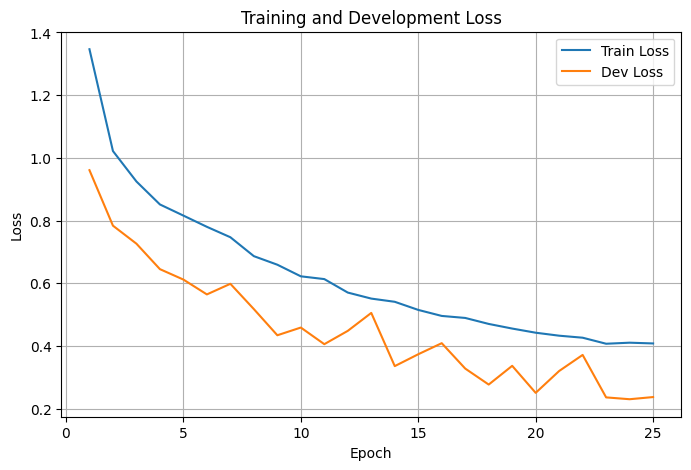

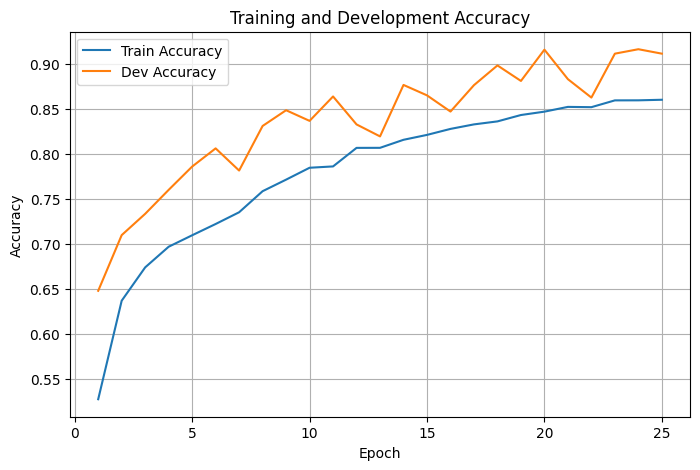

In [20]:
plot_training_history(sat_history)

In [21]:
# For this experiment, corruption means BLUR ONLY.
# Blur is used only during corrupted test evaluation, not during autoencoder training.
blur_transform = T.GaussianBlur(
    kernel_size=5,
    sigma=(0.8, 1.5)
)


def blur_image(image):
    return blur_transform(image.clone()).clamp(0, 1)


# **Function to train the autoencoder on original images only**

In [22]:
# Train autoencoder on original clean images only.
# The original clean image is both the input and reconstruction target.
def train_autoencoder(
    model,
    train_loader,
    dev_loader,
    optimizer,
    criterion,
    epochs,
    device
):
    model = model.to(device)

    best_dev_loss = float("inf")
    best_epoch = 0
    best_weights = None
    history = {"train_loss": [], "dev_loss": []}

    for epoch in range(1, epochs + 1):

        # Training
        model.train()
        train_loss = 0.0

        for images, _ in tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} Train",
            leave=False
        ):
            clean_images = images.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(set_to_none=True)

            reconstructed = model(clean_images)

            loss = criterion(
                reconstructed,
                clean_images
            )

            loss.backward()
            optimizer.step()

            train_loss += (
                loss.item() * clean_images.size(0)
            )

        train_loss /= len(train_loader.dataset)

        # Development on original clean images only.
        model.eval()
        dev_loss = 0.0

        with torch.no_grad():
            for images, _ in tqdm(
                dev_loader,
                desc=f"Epoch {epoch}/{epochs} Dev",
                leave=False
            ):
                clean_images = images.to(
                    device,
                    non_blocking=True
                )

                reconstructed = model(clean_images)

                loss = criterion(
                    reconstructed,
                    clean_images
                )

                dev_loss += (
                    loss.item() * clean_images.size(0)
                )

        dev_loss /= len(dev_loader.dataset)

        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)

        # Save best checkpoint.
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_epoch = epoch
            best_weights = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train MSE: {train_loss:.6f} | "
            f"Dev MSE: {dev_loss:.6f}"
        )

    # Load checkpoint with lowest development MSE.
    model.load_state_dict(best_weights)

    print(
        f"\nBest Epoch: {best_epoch} | "
        f"Best Dev MSE: {best_dev_loss:.6f}"
    )

    return model, history


# **Training the autoencoder: original → original**

In [23]:
# Create autoencoder
autoencoder = AutoEncoder().to(device)

# Reconstruction loss
reconstruction_criterion = nn.MSELoss()

# Optimizer
ae_optimizer = optim.AdamW(
    autoencoder.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [24]:
show_model_summary(autoencoder)

ae_total_params = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
)

print("Autoencoder total parameters:", ae_total_params)


Autoencoder total parameters: 50773


Epoch 1/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 1/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 01/25 | Train MSE: 0.010802 | Dev MSE: 0.003320


Epoch 2/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 2/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

...

Epoch 24/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 24/25 | Train MSE: 0.001996 | Dev MSE: 0.001482


Epoch 25/25 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 25/25 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 25/25 | Train MSE: 0.001990 | Dev MSE: 0.002475

Best Epoch: 15 | Best Dev MSE: 0.001100


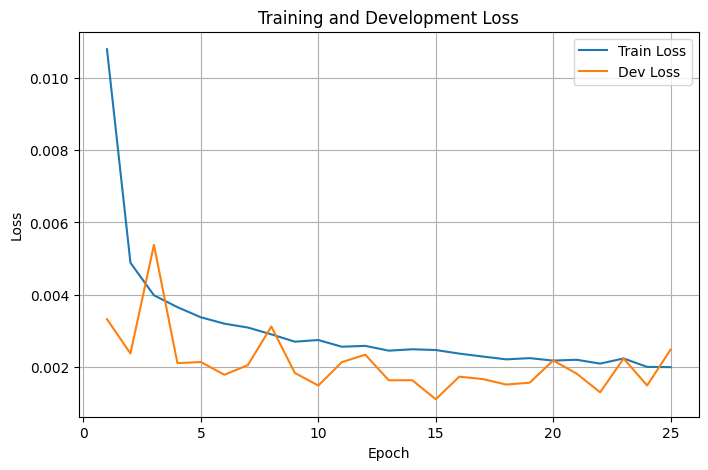

In [25]:
# Train autoencoder
autoencoder, ae_history = train_autoencoder(
    model=autoencoder,
    train_loader=train_loader,
    dev_loader=dev_loader,
    optimizer=ae_optimizer,
    criterion=reconstruction_criterion,
    epochs=25,
    device=device
)

plot_training_history(ae_history)

In [26]:
def show_original_blurred_reconstructed(
    autoencoder,
    data_loader,
    device,
    num_images=6
):
    autoencoder.eval()

    images, labels = next(iter(data_loader))

    num_images = min(num_images, len(images))
    images = images[:num_images]
    labels = labels[:num_images]

    # Create blurred versions from the same original images
    blurred = torch.stack([
        blur_image(image.clone())
        for image in images
    ])

    blurred_device = blurred.to(device)

    # Reconstruct blurred images
    with torch.no_grad():
        reconstructed = autoencoder(
            blurred_device
        )

    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(
        3,
        num_images,
        figsize=(3 * num_images, 8),
        squeeze=False
    )

    for i in range(num_images):

        # Original
        axes[0, i].imshow(
            images[i]
            .permute(1, 2, 0)
            .clamp(0, 1)
        )
        axes[0, i].set_title(
            f"Original\n{dataset.classes[labels[i]]}"
        )
        axes[0, i].axis("off")

        # Blurred
        axes[1, i].imshow(
            blurred[i]
            .permute(1, 2, 0)
            .clamp(0, 1)
        )
        axes[1, i].set_title("Blurred")
        axes[1, i].axis("off")

        # Reconstructed
        axes[2, i].imshow(
            reconstructed[i]
            .permute(1, 2, 0)
            .clamp(0, 1)
        )
        axes[2, i].set_title("Reconstructed")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

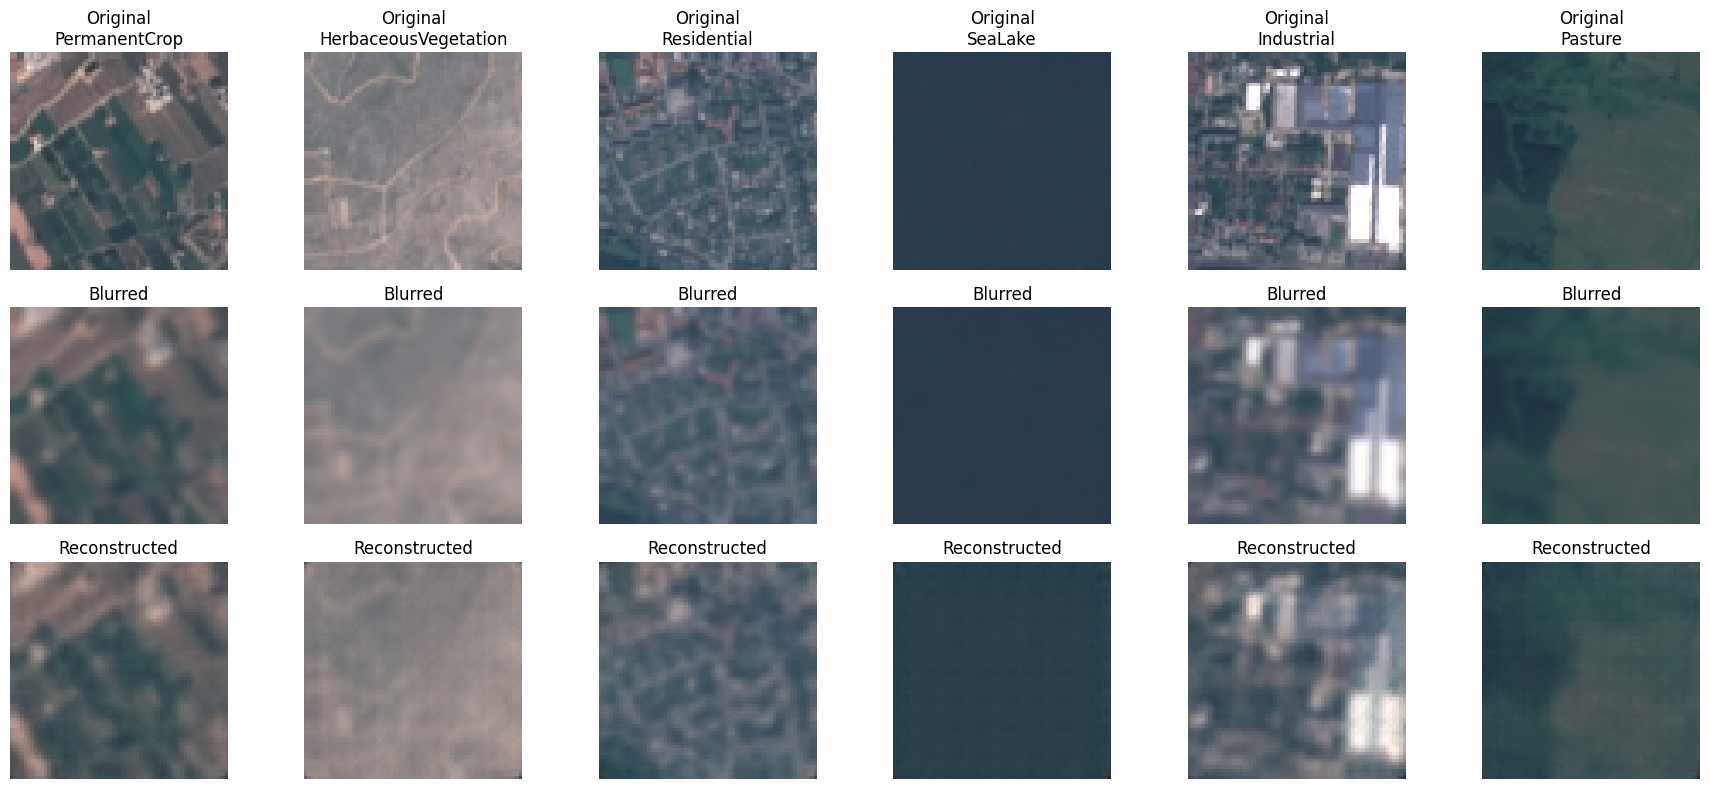

In [27]:
show_original_blurred_reconstructed(
    autoencoder,
    test_loader,
    device,
    num_images=6
)

# **Training AE-SAT-CNN from scratch using autoencoder outputs**

`ae_sat_cnn` uses the same `Sat_CNN` architecture, but it starts from a fresh random initialization. No weights are copied from `sat_cnn`. During training, each image is first reconstructed by the trained autoencoder, and that reconstructed image is then used to train `ae_sat_cnn`.


In [28]:
# Freeze the trained autoencoder. It is preprocessing only during classifier training.
autoencoder.eval()
for parameter in autoencoder.parameters():
    parameter.requires_grad = False

# Create a NEW classifier with the exact same architecture as sat_cnn.
# No weights are copied from sat_cnn.
ae_sat_cnn = Sat_CNN(
    num_classes=len(dataset.classes)
).to(device)

show_model_summary(ae_sat_cnn)

# Use two GPUs when available; also works on one GPU or CPU.
if torch.cuda.device_count() >= 2 and not isinstance(ae_sat_cnn, nn.DataParallel):
    ae_sat_cnn = nn.DataParallel(
        ae_sat_cnn,
        device_ids=[0, 1],
        output_device=0
    )

ae_optimizer = optim.AdamW(
    ae_sat_cnn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(
    "AE-SAT-CNN trainable parameters:",
    sum(
        parameter.numel()
        for parameter in ae_sat_cnn.parameters()
        if parameter.requires_grad
    )
)


AE-SAT-CNN trainable parameters: 200014


Epoch 1/35 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 1/35 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 01/35
Train | Loss: 1.4277 | Acc: 0.4873 | Prec: 0.4710 | Recall: 0.4745 | F1: 0.4608
Dev   | Loss: 0.9723 | Acc: 0.6310 | Prec: 0.6283 | Recall: 0.6127 | F1: 0.5948


Epoch 2/35 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 2/35 Dev:   0%|          | 0/64 [00:00<?, ?it/s]

...

Epoch 34/35 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 34/35
Train | Loss: 0.5003 | Acc: 0.8201 | Prec: 0.8155 | Recall: 0.8163 | F1: 0.8158
Dev   | Loss: 0.3300 | Acc: 0.8832 | Prec: 0.8804 | Recall: 0.8839 | F1: 0.8804


Epoch 35/35 Train:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 35/35 Dev:   0%|          | 0/64 [00:00<?, ?it/s]


Epoch 35/35
Train | Loss: 0.4914 | Acc: 0.8268 | Prec: 0.8224 | Recall: 0.8233 | F1: 0.8227
Dev   | Loss: 0.3604 | Acc: 0.8652 | Prec: 0.8669 | Recall: 0.8618 | F1: 0.8609

Selected Model
Epoch: 34 | Dev Loss: 0.3300 | Dev Acc: 0.8832 | Dev F1: 0.8804


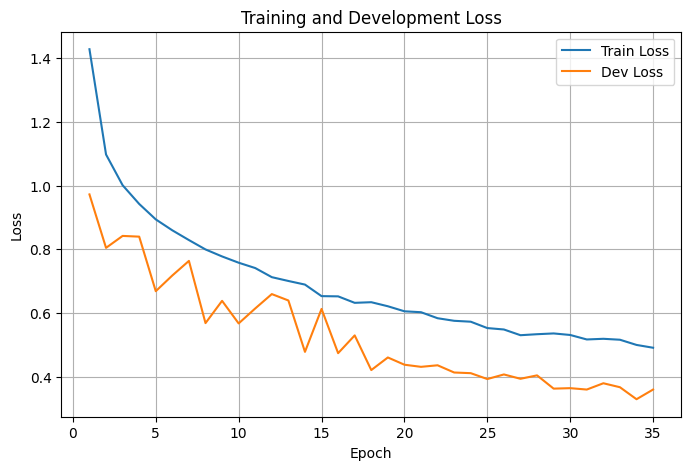

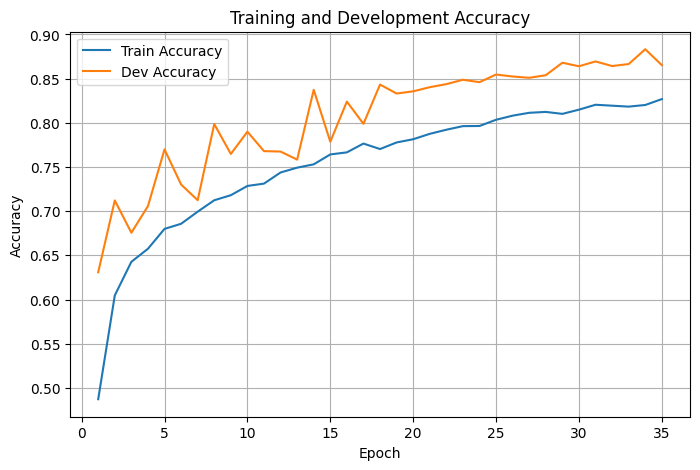

In [29]:
# Train ae_sat_cnn from scratch.
# Training path: image -> trained autoencoder -> ae_sat_cnn
ae_sat_cnn, ae_sat_history, ae_sat_checkpoints = train_classifier(
    model=ae_sat_cnn,
    train_loader=train_loader,
    dev_loader=dev_loader,
    optimizer=ae_optimizer,
    criterion=classification_criterion,
    epochs=35,
    device=device,
    checkpoint_dir="ae_sat_cnn_checkpoints",
    resume=True,
    preprocessor=autoencoder
)

plot_training_history(ae_sat_history)


# **Test Evaluation — four simple cases**

The two classifiers are trained independently. `sat_cnn` receives images directly, while `ae_sat_cnn` always receives the autoencoder reconstruction first.

1. **Clean → `sat_cnn`**
2. **Clean → autoencoder → `ae_sat_cnn`**
3. **Blurred → `sat_cnn`**
4. **Blurred → autoencoder → `ae_sat_cnn`**

Here, **clean/raw** means the original unblurred test images.


In [30]:
# Small helper only for collecting the final metrics.
# The image/model path stays visible inside each test cell.
def summarize_test(total_loss, total_samples, labels, predictions):
    result = {
        "loss": total_loss / total_samples,
        **get_metrics(labels, predictions)
    }

    for name, value in result.items():
        print(f"{name}: {value:.4f}")

    return result


## **1. Clean test images → sat_cnn**

Data path:

`clean test images → sat_cnn → predictions`


In [31]:
sat_cnn.eval()

sat_clean_loss = 0.0
sat_clean_labels = []
sat_clean_predictions = []

with torch.no_grad():
    for clean_images, labels in tqdm(
        test_loader,
        desc="Clean images -> sat_cnn"
    ):
        clean_images = clean_images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clean images go directly into sat_cnn.
        logits = sat_cnn(clean_images)

        loss = classification_criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        sat_clean_loss += loss.item() * labels.size(0)
        sat_clean_labels.extend(labels.cpu().tolist())
        sat_clean_predictions.extend(predictions.cpu().tolist())

print("sat_cnn on clean test images")
sat_clean_result = summarize_test(
    sat_clean_loss,
    len(sat_clean_labels),
    sat_clean_labels,
    sat_clean_predictions
)


Clean images -> sat_cnn:   0%|          | 0/64 [00:00<?, ?it/s]

sat_cnn on clean test images
loss: 0.2306
accuracy: 0.9212
precision: 0.9255
recall: 0.9176
f1: 0.9195


## **2. Clean test images → autoencoder → ae_sat_cnn**

Data path:

`clean test images → autoencoder → reconstructed images → ae_sat_cnn → predictions`

This shows what happens when the copied classifier receives autoencoder output even though the test images were not blurred first.


In [32]:
autoencoder.eval()
ae_sat_cnn.eval()

ae_clean_loss = 0.0
ae_clean_labels = []
ae_clean_predictions = []

with torch.no_grad():
    for clean_images, labels in tqdm(
        test_loader,
        desc="Clean images -> AE -> ae_sat_cnn"
    ):
        clean_images = clean_images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Step 1: clean test images enter the autoencoder.
        reconstructed_images = autoencoder(clean_images)

        # Step 2: autoencoder output enters the independently trained ae_sat_cnn.
        logits = ae_sat_cnn(reconstructed_images)

        loss = classification_criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        ae_clean_loss += loss.item() * labels.size(0)
        ae_clean_labels.extend(labels.cpu().tolist())
        ae_clean_predictions.extend(predictions.cpu().tolist())

print("ae_sat_cnn on clean test images after autoencoder")
ae_clean_result = summarize_test(
    ae_clean_loss,
    len(ae_clean_labels),
    ae_clean_labels,
    ae_clean_predictions
)


Clean images -> AE -> ae_sat_cnn:   0%|          | 0/64 [00:00<?, ?it/s]

ae_sat_cnn on clean test images after autoencoder
loss: 0.3291
accuracy: 0.8869
precision: 0.8836
recall: 0.8868
f1: 0.8839


## **3. Blurred test images → sat_cnn**

Data path:

`clean test images → Gaussian blur only → blurred images → sat_cnn → predictions`

A fixed seed is used so Case 3 and Case 4 receive the same blurred test images.


In [33]:
TEST_BLUR_SEED = 42

sat_blurred_loss = 0.0
sat_blurred_labels = []
sat_blurred_predictions = []

sat_cnn.eval()

with torch.random.fork_rng(devices=[]), torch.no_grad():
    torch.manual_seed(TEST_BLUR_SEED)

    for clean_images, labels in tqdm(
        test_loader,
        desc="Blurred images -> sat_cnn"
    ):
        # Step 1: blur the clean test images on CPU.
        blurred_images = torch.stack([
            blur_image(image)
            for image in clean_images
        ])

        # Step 2: move blurred images and labels to the model device.
        blurred_images = blurred_images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Step 3: blurred images go directly into sat_cnn.
        logits = sat_cnn(blurred_images)

        loss = classification_criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        sat_blurred_loss += loss.item() * labels.size(0)
        sat_blurred_labels.extend(labels.cpu().tolist())
        sat_blurred_predictions.extend(predictions.cpu().tolist())

print("sat_cnn on blurred test images")
sat_blurred_result = summarize_test(
    sat_blurred_loss,
    len(sat_blurred_labels),
    sat_blurred_labels,
    sat_blurred_predictions
)


Blurred images -> sat_cnn:   0%|          | 0/64 [00:00<?, ?it/s]

sat_cnn on blurred test images
loss: 1.7012
accuracy: 0.6114
precision: 0.7847
recall: 0.6110
f1: 0.5985


## **4. Blurred test images → autoencoder → ae_sat_cnn**

This is the full denoising path.

Data path:

`clean test images`
→ `Gaussian blur only`
→ `blurred images`
→ `autoencoder`
→ `denoised/reconstructed images`
→ `ae_sat_cnn`
→ `predictions`

The same blur seed from Case 3 is reset here, so the blurred images are reproduced in the same order.


In [34]:
ae_blurred_loss = 0.0
ae_blurred_labels = []
ae_blurred_predictions = []

autoencoder.eval()
ae_sat_cnn.eval()

with torch.random.fork_rng(devices=[]), torch.no_grad():
    torch.manual_seed(TEST_BLUR_SEED)

    for clean_images, labels in tqdm(
        test_loader,
        desc="Blurred images -> AE -> ae_sat_cnn"
    ):
        # Step 1: start with clean test images.
        # clean_images shape: [batch, 3, 64, 64]

        # Step 2: apply Gaussian blur only.
        blurred_images = torch.stack([
            blur_image(image)
            for image in clean_images
        ])

        # Step 3: move blurred images to the model device.
        blurred_images = blurred_images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Step 4: denoise/reconstruct the blurred images.
        denoised_images = autoencoder(blurred_images)

        # Step 5: send the denoised images into ae_sat_cnn.
        logits = ae_sat_cnn(denoised_images)

        # Step 6: get predictions.
        loss = classification_criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        ae_blurred_loss += loss.item() * labels.size(0)
        ae_blurred_labels.extend(labels.cpu().tolist())
        ae_blurred_predictions.extend(predictions.cpu().tolist())

print("ae_sat_cnn on blurred test images after autoencoder denoising")
ae_blurred_result = summarize_test(
    ae_blurred_loss,
    len(ae_blurred_labels),
    ae_blurred_labels,
    ae_blurred_predictions
)


Blurred images -> AE -> ae_sat_cnn:   0%|          | 0/64 [00:00<?, ?it/s]

ae_sat_cnn on blurred test images after autoencoder denoising
loss: 0.6340
accuracy: 0.8012
precision: 0.8307
recall: 0.8031
f1: 0.8005


## **Trace one blurred batch visually**

This cell shows exactly what enters each stage of the AE path:

`original → blurred → autoencoder reconstruction`


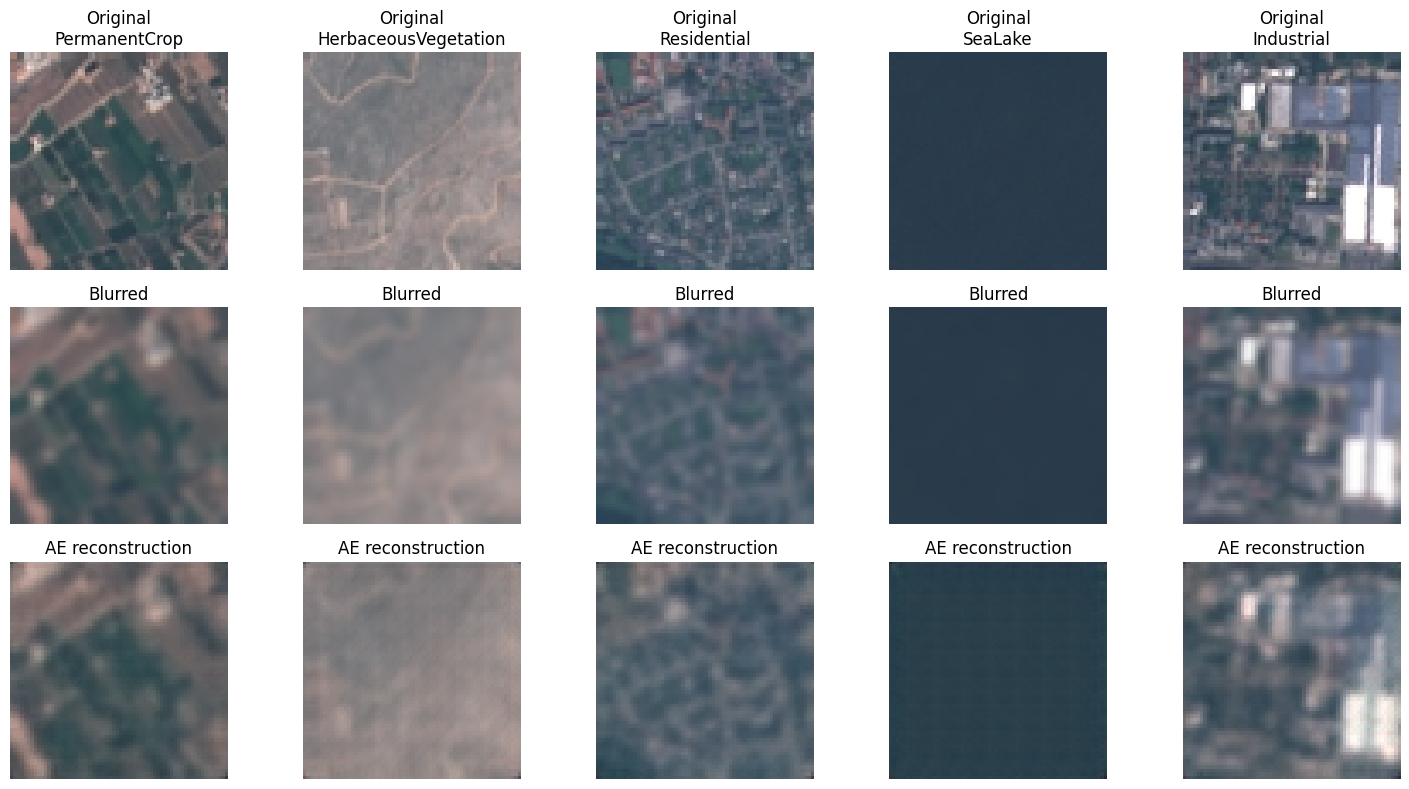

In [35]:
# Take one test batch.
trace_clean, trace_labels = next(iter(test_loader))

# Use the same blur seed as the blurred evaluations.
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(TEST_BLUR_SEED)

    trace_blurred = torch.stack([
        blur_image(image)
        for image in trace_clean
    ])

# Reconstruct the blurred images.
with torch.no_grad():
    trace_denoised = autoencoder(
        trace_blurred.to(device)
    ).cpu()

num_images = 5

fig, axes = plt.subplots(
    3,
    num_images,
    figsize=(15, 8)
)

for i in range(num_images):
    axes[0, i].imshow(
        trace_clean[i].permute(1, 2, 0).clamp(0, 1)
    )
    axes[0, i].set_title(
        f"Original\n{dataset.classes[trace_labels[i]]}"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        trace_blurred[i].permute(1, 2, 0).clamp(0, 1)
    )
    axes[1, i].set_title("Blurred")
    axes[1, i].axis("off")

    axes[2, i].imshow(
        trace_denoised[i].permute(1, 2, 0).clamp(0, 1)
    )
    axes[2, i].set_title("AE reconstruction")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()


## **Simple final summary**

The four rows below are only a compact recap of the four separate experiments above.


In [36]:
final_results = pd.DataFrame([
    {
        "Test input": "Clean",
        "Path": "sat_cnn",
        **sat_clean_result
    },
    {
        "Test input": "Clean",
        "Path": "autoencoder -> ae_sat_cnn",
        **ae_clean_result
    },
    {
        "Test input": "Blurred",
        "Path": "sat_cnn",
        **sat_blurred_result
    },
    {
        "Test input": "Blurred",
        "Path": "autoencoder -> ae_sat_cnn",
        **ae_blurred_result
    }
])

final_results.round(4)


,Test input,Path,loss,accuracy,precision,recall,f1
0,Clean,sat_cnn,0.2306,0.9212,0.9255,0.9176,0.9195
1,Clean,autoencoder -> ae_sat_cnn,0.3291,0.8869,0.8836,0.8868,0.8839
2,Blurred,sat_cnn,1.7012,0.6114,0.7847,0.6110,0.5985
3,Blurred,autoencoder -> ae_sat_cnn,0.6340,0.8012,0.8307,0.8031,0.8005
